In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv("Salary_Data.csv")

In [43]:
X = df['YearsExperience']
y = df['Salary']

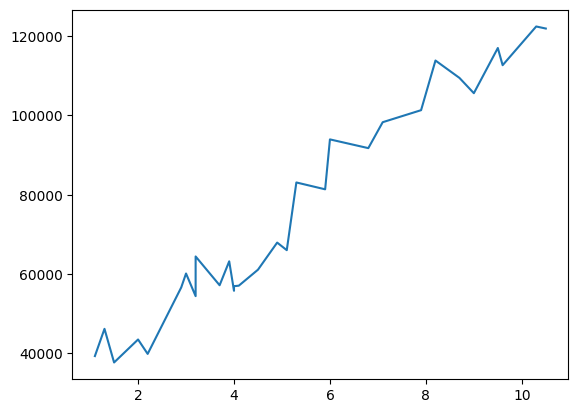

In [44]:
plt.plot(X,y)

In [45]:
def mean(X):
  return np.sum(X)/len(X)

def variance(X):
  mean_val = mean(X)
  return np.sum((X - mean_val)**2)/len(X)

In [46]:
def norm(X):
  mean_value = mean(X)
  variance_value = variance(X)
  return (X - mean_value)/np.sqrt(variance_value)

In [47]:
X_norm = norm(X)
X_norm

,YearsExperience
0,-1.510053
1,-1.438373
2,-1.366693
3,-1.187494
4,-1.115814
5,-0.864935
6,-0.829096
7,-0.757416
8,-0.757416
9,-0.578216


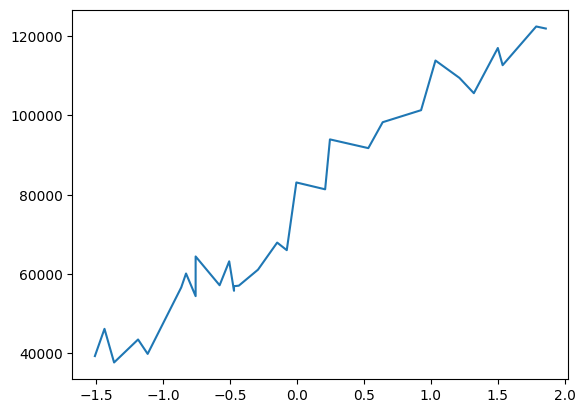

In [48]:
plt.plot(X_norm,y)

In [49]:
class SimpleLR:
  def __init__(self,lr=0.1,max_iter=2000,threshold=1e-6):
    self.lr = lr                           # Learning Rate
    self.max_iter = max_iter               # Maximun Iterations
    self.threshold = threshold             # Least Loss When Algo Should Be Stopped
    self.weight = np.random.uniform(1,-1)  # Slope or Coefficient
    self.bias = np.random.uniform(-1,1)    # Intercept

  def predict(self,X):
    return self.weight*X + self.bias

  def fit(self,X,y):
    n = len(X)
    loss_history = []
    y_pred = self.predict(X)
    errors = y - y_pred
    prev_loss = (1/(2*n)) * np.sum(errors**2)
    loss_history.append(prev_loss)

    for i in range(self.max_iter):
      w_grad = (1/n) * np.sum(errors*X)
      b_grad = (1/n) * np.sum(errors)
      self.weight += self.lr * w_grad
      self.bias += self.lr * b_grad
      y_pred = self.predict(X)
      errors = y - y_pred
      curr_loss = (1/(2*n)) * np.sum(errors**2)
      if np.abs(curr_loss - prev_loss) < self.threshold:
        break
      prev_loss = curr_loss
      loss_history.append(curr_loss)
    return loss_history

  def plot(self,X,y):
    y_pred = self.predict(X)
    plt.plot(X,y)
    plt.plot(X,y_pred)

  def predict_salary(self,exp):
    mean_val = mean(X)
    var_val = variance(X)
    X_norm = (exp - mean_val)/np.sqrt(var_val)
    return self.weight*X_norm + self.bias

In [50]:
model = SimpleLR()

In [51]:
loss_history = model.fit(X_norm,y)

In [52]:
loss_history

[np.float64(3251506430.663026),
 np.float64(2636690949.250667),
 np.float64(2138690409.306657),
 np.float64(1735309971.9520092),
 np.float64(1408571817.6947439),
 np.float64(1143913912.7463593),
 np.float64(929541009.7381676),
 np.float64(755898958.3015324),
 np.float64(615248896.6378579),
 np.float64(501322346.6902816),
 np.float64(409041841.2327449),
 np.float64(334294631.81214),
 np.float64(273749392.1814502),
 np.float64(224707748.08059126),
 np.float64(184984016.3588956),
 np.float64(152807793.66432208),
 np.float64(126745053.28171758),
 np.float64(105634233.57180794),
 np.float64(88534469.60678115),
 np.float64(74683660.7951095),
 np.float64(63464505.65765533),
 np.float64(54376989.9963175),
 np.float64(47016102.31063391),
 np.float64(41053783.28523014),
 np.float64(36224304.87465313),
 np.float64(32312427.362085693),
 np.float64(29143806.576906107),
 np.float64(26577223.740910612),
 np.float64(24498291.643754266),
 np.float64(22814356.645057645),
 np.float64(21450369.29611336),


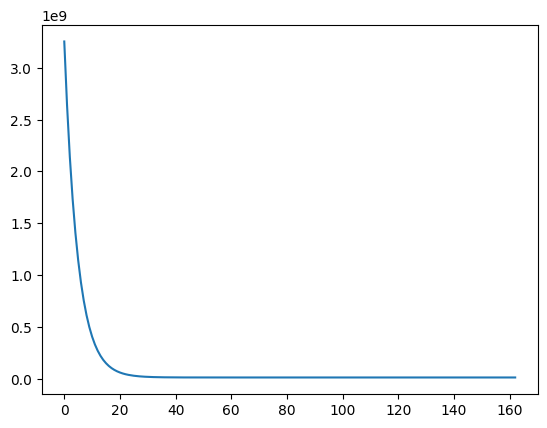

In [53]:
plt.plot(loss_history)

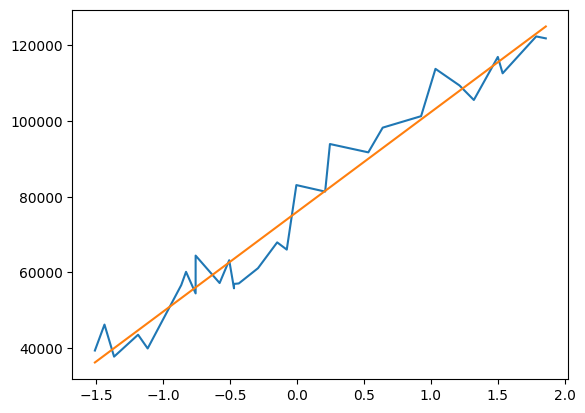

In [54]:
model.plot(X_norm,y)

In [55]:
x = 2
model.predict_salary(x)

np.float64(44692.12328651111)